# Simple Model: BRNS vs. Stationary Analytical Solution

This notebook compares the numerical BRNS result of `models/simple/simple.yaml` against the stationary analytical solution of the simplified 1D advection-diffusion-reaction problem for the irreversible transformation $A \\rightarrow B$.

The numerical reference is taken from the **last available time snapshot** in the BRNS `.dat` files, which is the closest available approximation to the stationary state.

## Analytical Model

For constant coefficients, the stationary dissolved-species equations are written as

$$
0 = D\frac{d^2 A}{dz^2} - v\frac{dA}{dz} - kA,
$$

$$
0 = D\frac{d^2 B}{dz^2} - v\frac{dB}{dz} + kA,
$$

with boundary conditions

$$
A(0)=1, \quad B(0)=0, \quad A'(L)=0, \quad B'(L)=0.
$$

Under these assumptions, $A+B=1$ and the stationary reaction-rate profile is simply $r(z)=kA(z)$.

In [1]:
from pathlib import Path
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

try:
    from notebooks.utils.helper import collect_dat_datasets, split_snapshots
except ModuleNotFoundError:
    from utils.helper import collect_dat_datasets, split_snapshots

RESULT_DIR = Path(os.environ.get('BRNS_SIMPLE_RESULT_DIR', 'generated_fortran/simple/simple/results'))
FIGURE_PATH = Path(os.environ.get('BRNS_SIMPLE_FIGURE', 'paper/simple_stationary_analytic_comparison.pdf'))

MODEL_PARAMS = {
    'L': 0.1,
    'D': 1.0e-9,
    'v': 1.0e-4,
    'k': 2.0e-3,
    'A_top': 1.0,
    'B_top': 0.0,
}

print('Result directory:', RESULT_DIR)
print('Exists          :', RESULT_DIR.exists())
print('Figure output   :', FIGURE_PATH)

if not RESULT_DIR.exists():
    warnings.warn(f'Result directory not found: {RESULT_DIR}')

datasets = collect_dat_datasets(RESULT_DIR)
required_files = ['species_a.dat', 'species_b.dat', 'rate_ab.dat']
missing_files = [name for name in required_files if name not in datasets]
if missing_files:
    raise FileNotFoundError(f'Missing required result files: {missing_files}')

print('.dat files loaded:', len(datasets))
for name in required_files:
    print(f'  - {name}: {datasets[name].shape[0]} rows')

Result directory: generated_fortran/simple/simple/results
Exists          : True
Figure output   : paper/simple_stationary_analytic_comparison.pdf
  Ladefehler conc.dat could not convert string 'conc' to float64 at row 0, column 1.
  Ladefehler echogrid.dat could not convert string 'echo' to float64 at row 0, column 1.
.dat files loaded: 3
  - species_a.dat: 1020 rows
  - species_b.dat: 1020 rows
  - rate_ab.dat: 1020 rows


In [2]:
def last_snapshot(arr: np.ndarray) -> np.ndarray:
    snaps = split_snapshots(arr)
    if not snaps:
        raise ValueError('Dataset contains no snapshots')
    return snaps[-1]


def stationary_species_a(depth: np.ndarray, *, D: float, v: float, k: float, L: float, A_top: float) -> np.ndarray:
    depth = np.asarray(depth, dtype=float)
    if D <= 0.0:
        beta = k / v
        return A_top * np.exp(-beta * depth)

    disc = np.sqrt(v ** 2 + 4.0 * D * k)
    r1 = (v + disc) / (2.0 * D)
    r2 = (v - disc) / (2.0 * D)

    # Stable representation around the lower boundary z=L.
    # This avoids overflow for exp(r1 * L) when D is very small.
    denom = np.exp(-r1 * L) - (r1 / r2) * np.exp(-r2 * L)
    coeff = A_top / denom
    return coeff * (
        np.exp(r1 * (depth - L)) - (r1 / r2) * np.exp(r2 * (depth - L))
    )


def stationary_solution(depth: np.ndarray, params: dict[str, float]) -> dict[str, np.ndarray]:
    depth = np.asarray(depth, dtype=float)
    a = stationary_species_a(depth, D=params['D'], v=params['v'], k=params['k'], L=params['L'], A_top=params['A_top'])
    b = params['A_top'] + params['B_top'] - a
    rate = params['k'] * a
    return {'species_a': a, 'species_b': b, 'rate_ab': rate}


sim_a = last_snapshot(datasets['species_a.dat'])
sim_b = last_snapshot(datasets['species_b.dat'])
sim_r = last_snapshot(datasets['rate_ab.dat'])
depth = sim_a[:, 1]
MODEL_PARAMS['L'] = float(np.max(depth))
analytic = stationary_solution(depth, MODEL_PARAMS)

print('Last snapshot rows:')
print('  species_a:', sim_a.shape[0])
print('  species_b:', sim_b.shape[0])
print('  rate_ab  :', sim_r.shape[0])
print('  domain L :', MODEL_PARAMS['L'])

Last snapshot rows:
  species_a: 51
  species_b: 51
  rate_ab  : 51
  domain L : 0.1


In [3]:
def compute_error(sim_values: np.ndarray, ref_values: np.ndarray, rel_floor: float = 1.0e-14) -> dict[str, np.ndarray | float]:
    sim_values = np.asarray(sim_values, dtype=float)
    ref_values = np.asarray(ref_values, dtype=float)
    diff = sim_values - ref_values
    abs_diff = np.abs(diff)
    rel_diff = abs_diff / np.maximum(np.abs(ref_values), rel_floor)
    return {
        'abs_diff': abs_diff,
        'rel_diff': rel_diff,
        'l2': float(np.sqrt(np.mean(diff ** 2))),
        'linf': float(np.max(abs_diff)),
        'abs_mean': float(np.mean(abs_diff)),
        'abs_max': float(np.max(abs_diff)),
        'rel_mean': float(np.mean(rel_diff)),
        'rel_max': float(np.max(rel_diff)),
    }


err_a = compute_error(sim_a[:, 0], analytic['species_a'])
err_b = compute_error(sim_b[:, 0], analytic['species_b'])
err_r = compute_error(sim_r[:, 0], analytic['rate_ab'])

deviation_profiles = {
    'species_a': err_a,
    'species_b': err_b,
    'rate_ab': err_r,
}

print('Error summary against the stationary analytical solution')
print('=' * 116)
print(f"{'Field':<12} {'L2 error':>14} {'Linf error':>14} {'Mean |abs|':>14} {'Max |abs|':>14} {'Mean rel [%]':>16} {'Max rel [%]':>16}")
print('-' * 116)
for field, err in [('species_a', err_a), ('species_b', err_b), ('rate_ab', err_r)]:
    print(f"{field:<12} {err['l2']:14.6e} {err['linf']:14.6e} {err['abs_mean']:14.6e} {err['abs_max']:14.6e} {100.0 * err['rel_mean']:16.6e} {100.0 * err['rel_max']:16.6e}")

Error summary against the stationary analytical solution
Field              L2 error     Linf error     Mean |abs|      Max |abs|     Mean rel [%]      Max rel [%]
--------------------------------------------------------------------------------------------------------------------
species_a      5.936645e-03   7.243940e-03   5.569302e-03   7.243940e-03     1.975257e+00     4.160001e+00
species_b      5.936645e-03   7.243940e-03   5.569303e-03   7.243940e-03     1.032033e+00     2.798653e+00
rate_ab        1.187329e-05   1.448798e-05   1.113861e-05   1.448798e-05     1.975256e+00     4.160001e+00


Saved figure to paper/simple_stationary_analytic_comparison.pdf


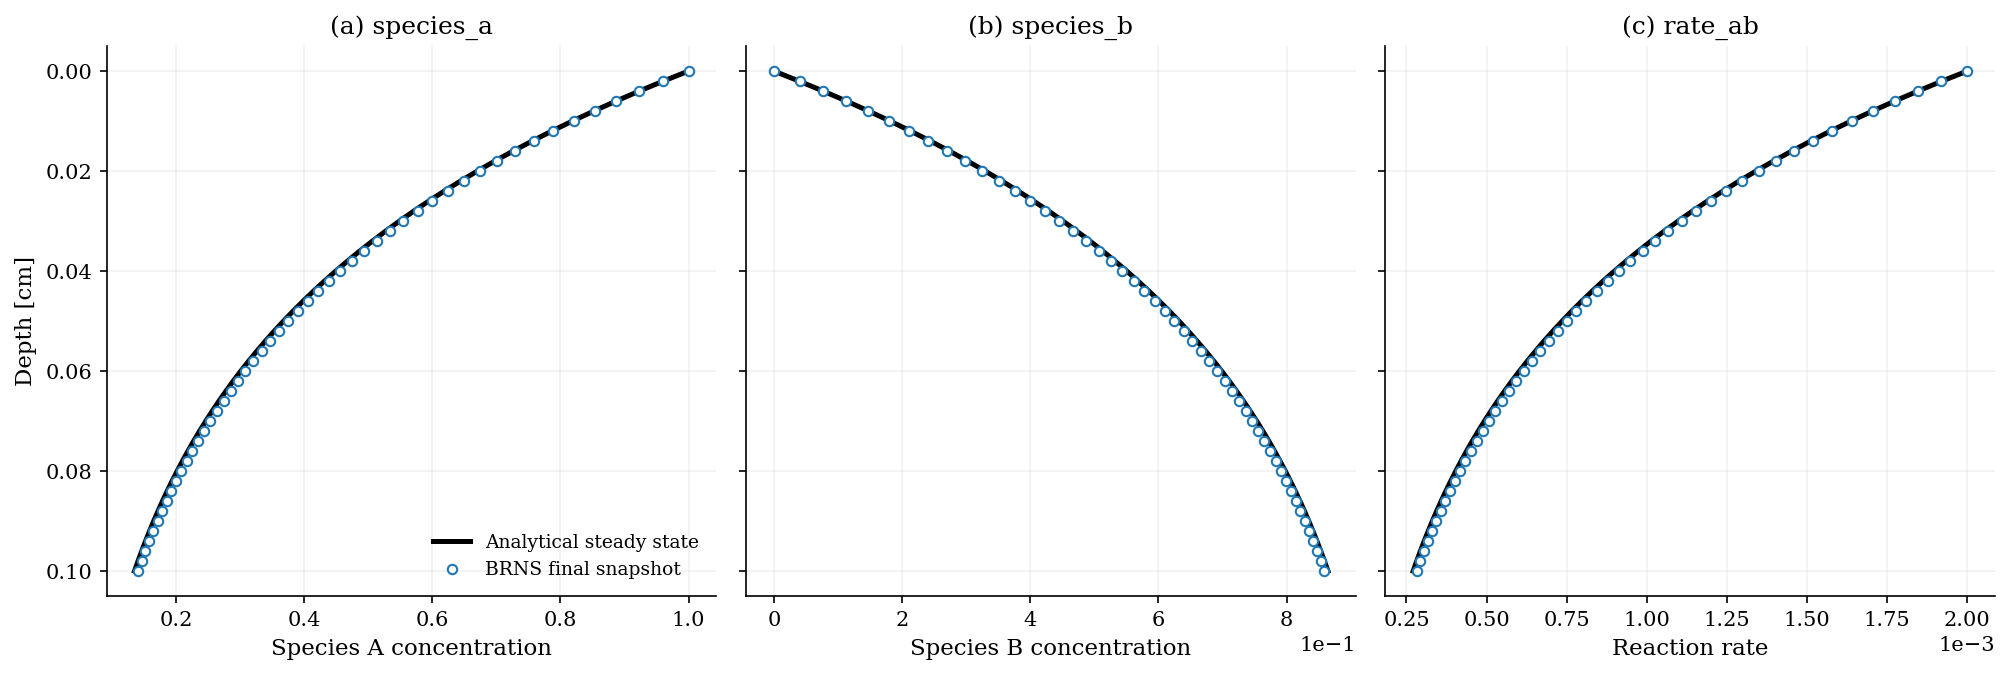

In [4]:
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'STIX Two Text', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
})

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), sharey=True)
series = [
    ('species_a', sim_a[:, 0], analytic['species_a'], 'Species A concentration', '(a)'),
    ('species_b', sim_b[:, 0], analytic['species_b'], 'Species B concentration', '(b)'),
    ('rate_ab', sim_r[:, 0], analytic['rate_ab'], 'Reaction rate', '(c)'),
]

for ax, (name, sim_values, ref_values, xlabel, panel) in zip(axes, series):
    ax.plot(ref_values, depth, color='black', linewidth=2.4, label='Analytical steady state')
    ax.plot(sim_values, depth, linestyle='none', marker='o', markersize=4.5, markerfacecolor='white', markeredgewidth=1.0, color='#1f77b4', label='BRNS final snapshot')
    ax.set_xlabel(xlabel)
    ax.set_title(f'{panel} {name}')
    ax.grid(True, which='major', alpha=0.18)
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
    ax.invert_yaxis()

axes[0].set_ylabel('Depth [cm]')
axes[0].legend(loc='lower right', frameon=False)
#fig.suptitle('Simple BRNS model compared with the stationary analytical solution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PATH, bbox_inches='tight')
print('Saved figure to', FIGURE_PATH)
plt.show()

## Notes

- The analytical reference assumes **constant coefficients** and the **stationary** limit of the continuum equations documented in `docs/model.md`.
- The BRNS profile is taken from the **last available output snapshot**, which may still differ from the strict stationary limit if the run time is finite.
- If you want to compare another result directory, set `BRNS_SIMPLE_RESULT_DIR` before running the notebook.